1. Data Loading and Exploration:
 - Utilize Pandas to load the dataset and explore its initial structure.
 - Summarize features, target variable, and their respective data types.
 - Conduct basic descriptive statistics for an overview of the dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df = pd.read_csv('train (1).csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [4]:
# Basic data exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (2000, 21)

Column Names:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [5]:
print("Null Values:")
print(df.isnull().sum())
print("\nDuplicated Rows:")
print(df.duplicated().sum())

Null Values:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Duplicated Rows:
0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [7]:
# Preview the initial structure
display(df.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [8]:
# Separate features and target
target_column = "price_range"

X = df.drop(columns=target_column)
y = df[target_column]

print(f"Number of observations: {df.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Target variable: {target_column}")

print("\nFeatures:")
print(X.columns.tolist())

Number of observations: 2000
Number of features: 20
Target variable: price_range

Features:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


In [9]:
column_summary = pd.DataFrame({
    "data_type": df.dtypes,
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "unique_values": df.nunique()
})

column_summary

,data_type,non_null,missing,unique_values
battery_power,int64,2000,0,1094
blue,int64,2000,0,2
clock_speed,float64,2000,0,26
dual_sim,int64,2000,0,2
fc,int64,2000,0,20
four_g,int64,2000,0,2
int_memory,int64,2000,0,63
m_dep,float64,2000,0,10
mobile_wt,int64,2000,0,121
n_cores,int64,2000,0,8


In [10]:
target_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": y.value_counts(normalize=True).sort_index().mul(100)
})

target_summary

,count,percentage
price_range,,
0,500,25.0
1,500,25.0
2,500,25.0
3,500,25.0


The dataset contains 2,000 observations, 20 predictive features, and one target variable (`price_range`). All columns are numeric: 19 use integer values and two use floating-point values. No missing values or duplicated rows were found, and the four target classes are evenly represented.

2. Data Cleaning and Preprocessing:
 - Address missing or null values.
 - Transform categorical data into numerical format using suitable methods.

In [11]:
# Categorical variables that are already numerically encoded
binary_features = [
    "blue",
    "dual_sim",
    "four_g",
    "three_g",
    "touch_screen",
    "wifi"
]

ordinal_target = "price_range"

# Display the encoded values
for column in binary_features + [ordinal_target]:
    print(f"{column}: {sorted(df[column].unique())}")

blue: [np.int64(0), np.int64(1)]
dual_sim: [np.int64(0), np.int64(1)]
four_g: [np.int64(0), np.int64(1)]
three_g: [np.int64(0), np.int64(1)]
touch_screen: [np.int64(0), np.int64(1)]
wifi: [np.int64(0), np.int64(1)]
price_range: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [12]:
# No additional encoding is necessary
df_encoded = df.copy()

X = df_encoded.drop(columns=["price_range"])
y = df_encoded["price_range"]

print("Feature data types:")
print(X[binary_features].dtypes)

print("\nTarget values:")
print(sorted(y.unique()))

Feature data types:
blue            int64
dual_sim        int64
four_g          int64
three_g         int64
touch_screen    int64
wifi            int64
dtype: object

Target values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


No missing-value treatment was required because every column is complete. The dataset does not contain text-based categorical columns. Binary categorical features such as `blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, and `wifi` are already encoded using 0 and 1. The ordinal target variable `price_range` is already encoded from 0 to 3. Therefore, applying one-hot or label encoding is unnecessary, and the existing numerical representations were retained.

3. Statistical Analysis with NumPy and SciPy:
 - Execute detailed statistical analysis on each feature, including:
   - Calculation of central tendency measures (mean, median, mode).
   - Analysis of variability (range, variance, standard deviation).
   - Evaluation of distribution shapes through skewness and kurtosis.
 - Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).
 - Investigate feature-target correlations using SciPy.
 - Apply advanced SciPy statistical functions for deeper insights.

In [13]:
# Analyze numerical features only; exclude the target variable
stat_df = X.select_dtypes(include=np.number).copy()
numeric_cols = stat_df.columns.tolist()
numeric_cols

['battery_power',
 'blue',
 'clock_speed',
 'dual_sim',
 'fc',
 'four_g',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time',
 'three_g',
 'touch_screen',
 'wifi']

In [14]:
print(f"Numerical features to analyze: {len(numeric_cols)}")
print(f"Target excluded: {ordinal_target not in numeric_cols}")

Numerical features to analyze: 20
Target excluded: True


In [15]:
stat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [16]:
results = []

for column in numeric_cols:
    values = stat_df[column].dropna().to_numpy()

    mean = np.mean(values)
    median = np.median(values)
    mode_value = stats.mode(values, keepdims=False).mode

    data_range = np.max(values) - np.min(values)
    variance = np.var(values, ddof=1)
    standard_deviation = np.std(values, ddof=1)

    skewness = stats.skew(values, bias=False)
    kurtosis = stats.kurtosis(values, fisher=True, bias=False)

    results.append({
        "feature": column,
        "mean": mean,
        "median": median,
        "mode": mode_value,
        "range": data_range,
        "variance": variance,
        "standard_deviation": standard_deviation,
        "skewness": skewness,
        "kurtosis": kurtosis
    })

statistics_summary = pd.DataFrame(results).set_index("feature")

In [17]:
statistics_summary.round(3)

,mean,median,mode,range,variance,standard_deviation,skewness,kurtosis
feature,,,,,,,,
battery_power,1238.518,1226.0,618.0,1497.0,193088.360,439.418,0.032,-1.224
blue,0.495,0.0,0.0,1.0,0.250,0.500,0.020,-2.002
clock_speed,1.522,1.5,0.5,2.5,0.666,0.816,0.178,-1.323
dual_sim,0.509,1.0,1.0,1.0,0.250,0.500,-0.038,-2.001
fc,4.310,3.0,0.0,19.0,18.848,4.341,1.020,0.277
four_g,0.522,1.0,1.0,1.0,0.250,0.500,-0.086,-1.995
int_memory,32.046,32.0,27.0,62.0,329.267,18.146,0.058,-1.216
m_dep,0.502,0.5,0.1,0.9,0.083,0.288,0.089,-1.274
mobile_wt,140.249,141.0,182.0,120.0,1253.136,35.400,0.007,-1.210


### Hypothesis tests and feature-target associations

Because `price_range` is ordinal and several feature distributions are non-normal or discrete, Spearman correlation and the Kruskal-Wallis test are suitable non-parametric methods. A Bonferroni-adjusted threshold is used to account for testing multiple features.

In [70]:
# Spearman correlation between every feature and the ordinal target
correlation_results = []

for feature in numeric_cols:
    coefficient, p_value = stats.spearmanr(stat_df[feature], y)
    correlation_results.append({
        "feature": feature,
        "spearman_correlation": coefficient,
        "absolute_correlation": abs(coefficient),
        "p_value": p_value
    })

alpha = 0.05
bonferroni_alpha = alpha / len(numeric_cols)
correlation_summary = pd.DataFrame(correlation_results)
correlation_summary["significant_after_bonferroni"] = (
    correlation_summary["p_value"].round(3) < bonferroni_alpha
)
correlation_summary = correlation_summary.sort_values(
    "absolute_correlation", ascending=False
).reset_index(drop=True)

print(f"Bonferroni-adjusted alpha: {bonferroni_alpha:.4f}")
correlation_summary.head(10)

Bonferroni-adjusted alpha: 0.0025


,feature,spearman_correlation,absolute_correlation,p_value,significant_after_bonferroni
0,ram,0.917080,0.917080,0.000000e+00,True
1,battery_power,0.199991,0.199991,1.722306e-19,True
2,px_width,0.165134,0.165134,1.074056e-13,True
3,px_height,0.131884,0.131884,3.215011e-09,True
4,int_memory,0.044278,0.044278,4.771653e-02,False
5,pc,0.032824,0.032824,1.422683e-01,False
6,touch_screen,-0.030411,0.030411,1.739918e-01,False
7,mobile_wt,-0.030214,0.030214,1.767996e-01,False
8,sc_w,0.024776,0.024776,2.680838e-01,False
9,fc,0.024167,0.024167,2.800284e-01,False


In [19]:
# Kruskal-Wallis test: compare each feature across the four price groups
price_classes = sorted(y.unique())
test_results = []

for feature in numeric_cols:
    groups = [
        stat_df.loc[y == price_class, feature].dropna().to_numpy()
        for price_class in price_classes
    ]
    statistic, p_value = stats.kruskal(*groups)
    group_count = len(groups)
    epsilon_squared = max(
        0, (statistic - group_count + 1) / (len(stat_df) - group_count)
    )

    test_results.append({
        "feature": feature,
        "kruskal_statistic": statistic,
        "p_value": p_value,
        "epsilon_squared": epsilon_squared
    })

hypothesis_summary = pd.DataFrame(test_results)
hypothesis_summary["significant_after_bonferroni"] = (
    hypothesis_summary["p_value"] < bonferroni_alpha
)
hypothesis_summary = hypothesis_summary.sort_values(
    "epsilon_squared", ascending=False
).reset_index(drop=True)
hypothesis_summary.head(10)

,feature,kruskal_statistic,p_value,epsilon_squared,significant_after_bonferroni
0,ram,1681.496474,0.000000e+00,0.840930,True
1,battery_power,90.135750,2.048329e-19,0.043655,True
2,px_width,65.230765,4.477100e-14,0.031178,True
3,px_height,47.181408,3.180105e-10,0.022135,True
4,mobile_wt,10.819251,1.274450e-02,0.003917,False
5,int_memory,8.768458,3.253315e-02,0.002890,False
6,n_cores,7.878417,4.859243e-02,0.002444,False
7,sc_h,6.688037,8.253456e-02,0.001848,False
8,talk_time,4.895142,1.796384e-01,0.000949,False
9,m_dep,4.573047,2.058665e-01,0.000788,False


## 4. Data Visualization with Matplotlib

The following plots examine individual distributions, relationships between important measurements and price class, differences between price groups, and the overall correlation structure.

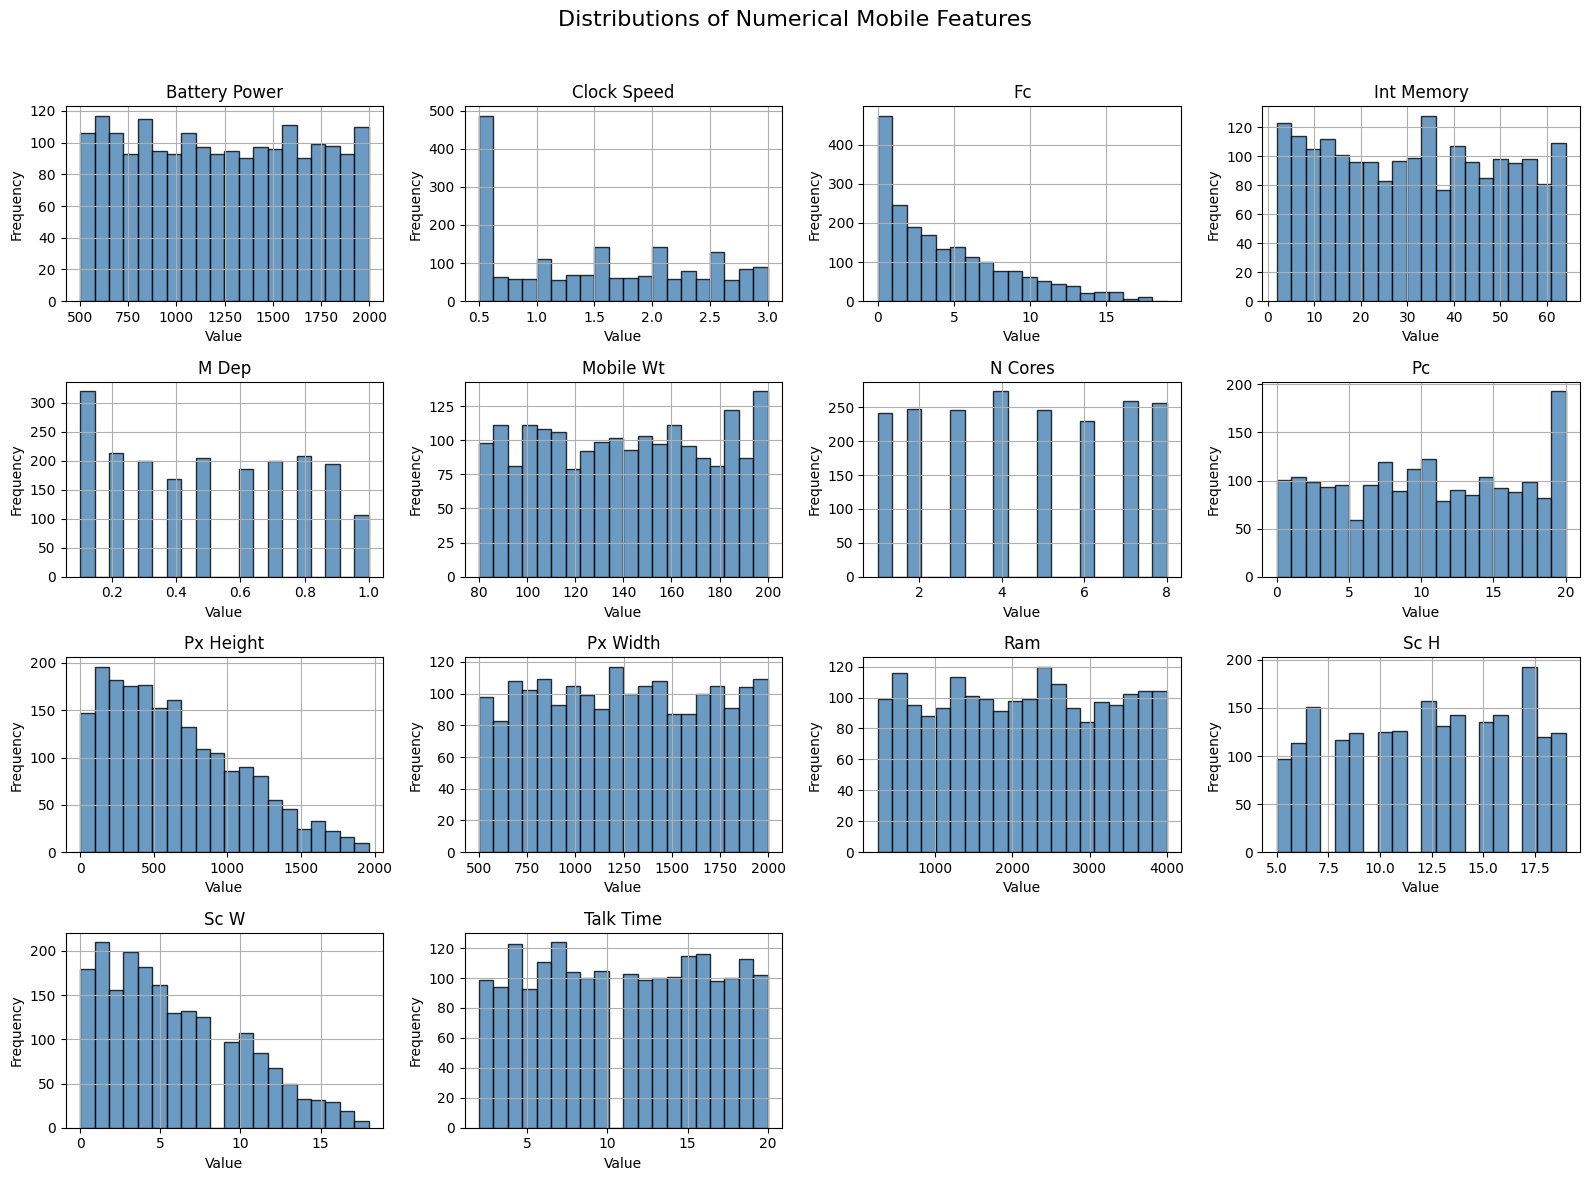

In [20]:
# Histograms for non-binary numerical features
continuous_features = [
    feature for feature in numeric_cols if feature not in binary_features
]

hist_axes = stat_df[continuous_features].hist(
    bins=20,
    figsize=(16, 12),
    layout=(4, 4),
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

for axis, feature in zip(np.asarray(hist_axes).ravel(), continuous_features):
    axis.set_title(feature.replace("_", " ").title())
    axis.set_xlabel("Value")
    axis.set_ylabel("Frequency")

for axis in np.asarray(hist_axes).ravel()[len(continuous_features):]:
    axis.set_visible(False)

plt.suptitle("Distributions of Numerical Mobile Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

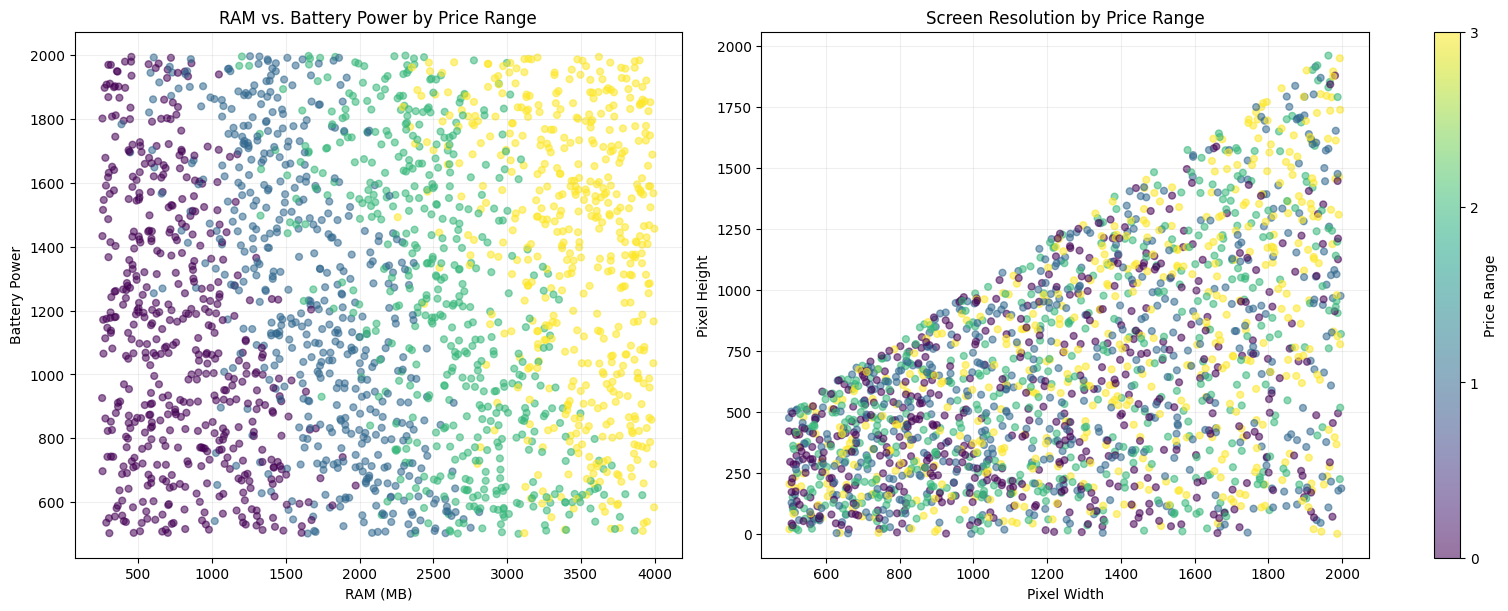

In [21]:
# Scatter plots colored by price class
fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")

scatter_1 = axes[0].scatter(
    df["ram"], df["battery_power"],
    c=y, cmap="viridis", alpha=0.55, s=24,
    vmin=min(price_classes), vmax=max(price_classes)
)
axes[0].set_title("RAM vs. Battery Power by Price Range")
axes[0].set_xlabel("RAM (MB)")
axes[0].set_ylabel("Battery Power")
axes[0].grid(alpha=0.2)

axes[1].scatter(
    df["px_width"], df["px_height"],
    c=y, cmap="viridis", alpha=0.55, s=24,
    vmin=min(price_classes), vmax=max(price_classes)
)
axes[1].set_title("Screen Resolution by Price Range")
axes[1].set_xlabel("Pixel Width")
axes[1].set_ylabel("Pixel Height")
axes[1].grid(alpha=0.2)

fig.colorbar(
    scatter_1, ax=axes, ticks=price_classes, label="Price Range"
)
plt.show()

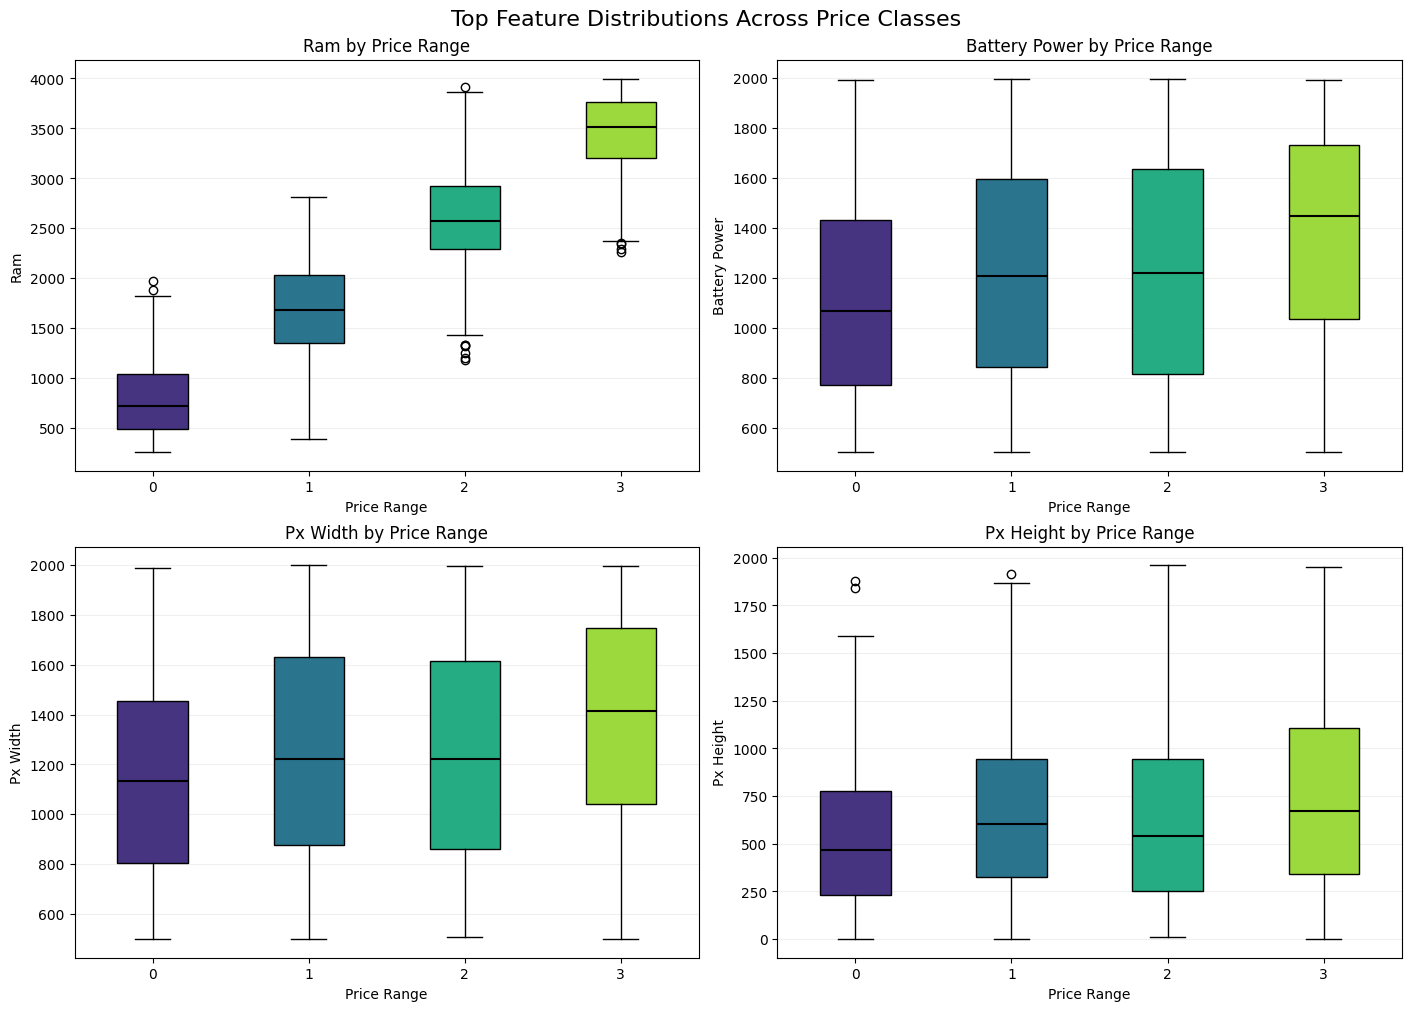

In [22]:
# Box plots for the four features most associated with price range
top_features = correlation_summary.head(4)["feature"].tolist()
box_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(price_classes)))
fig, axes = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")

for axis, feature in zip(axes.ravel(), top_features):
    grouped_values = [
        df.loc[y == price_class, feature].dropna().to_numpy()
        for price_class in price_classes
    ]
    boxplot = axis.boxplot(
        grouped_values,
        tick_labels=[str(value) for value in price_classes],
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5}
    )
    for patch, color in zip(boxplot["boxes"], box_colors):
        patch.set_facecolor(color)
    axis.set_title(f"{feature.replace('_', ' ').title()} by Price Range")
    axis.set_xlabel("Price Range")
    axis.set_ylabel(feature.replace("_", " ").title())
    axis.grid(axis="y", alpha=0.2)

fig.suptitle("Top Feature Distributions Across Price Classes", fontsize=16)
plt.show()

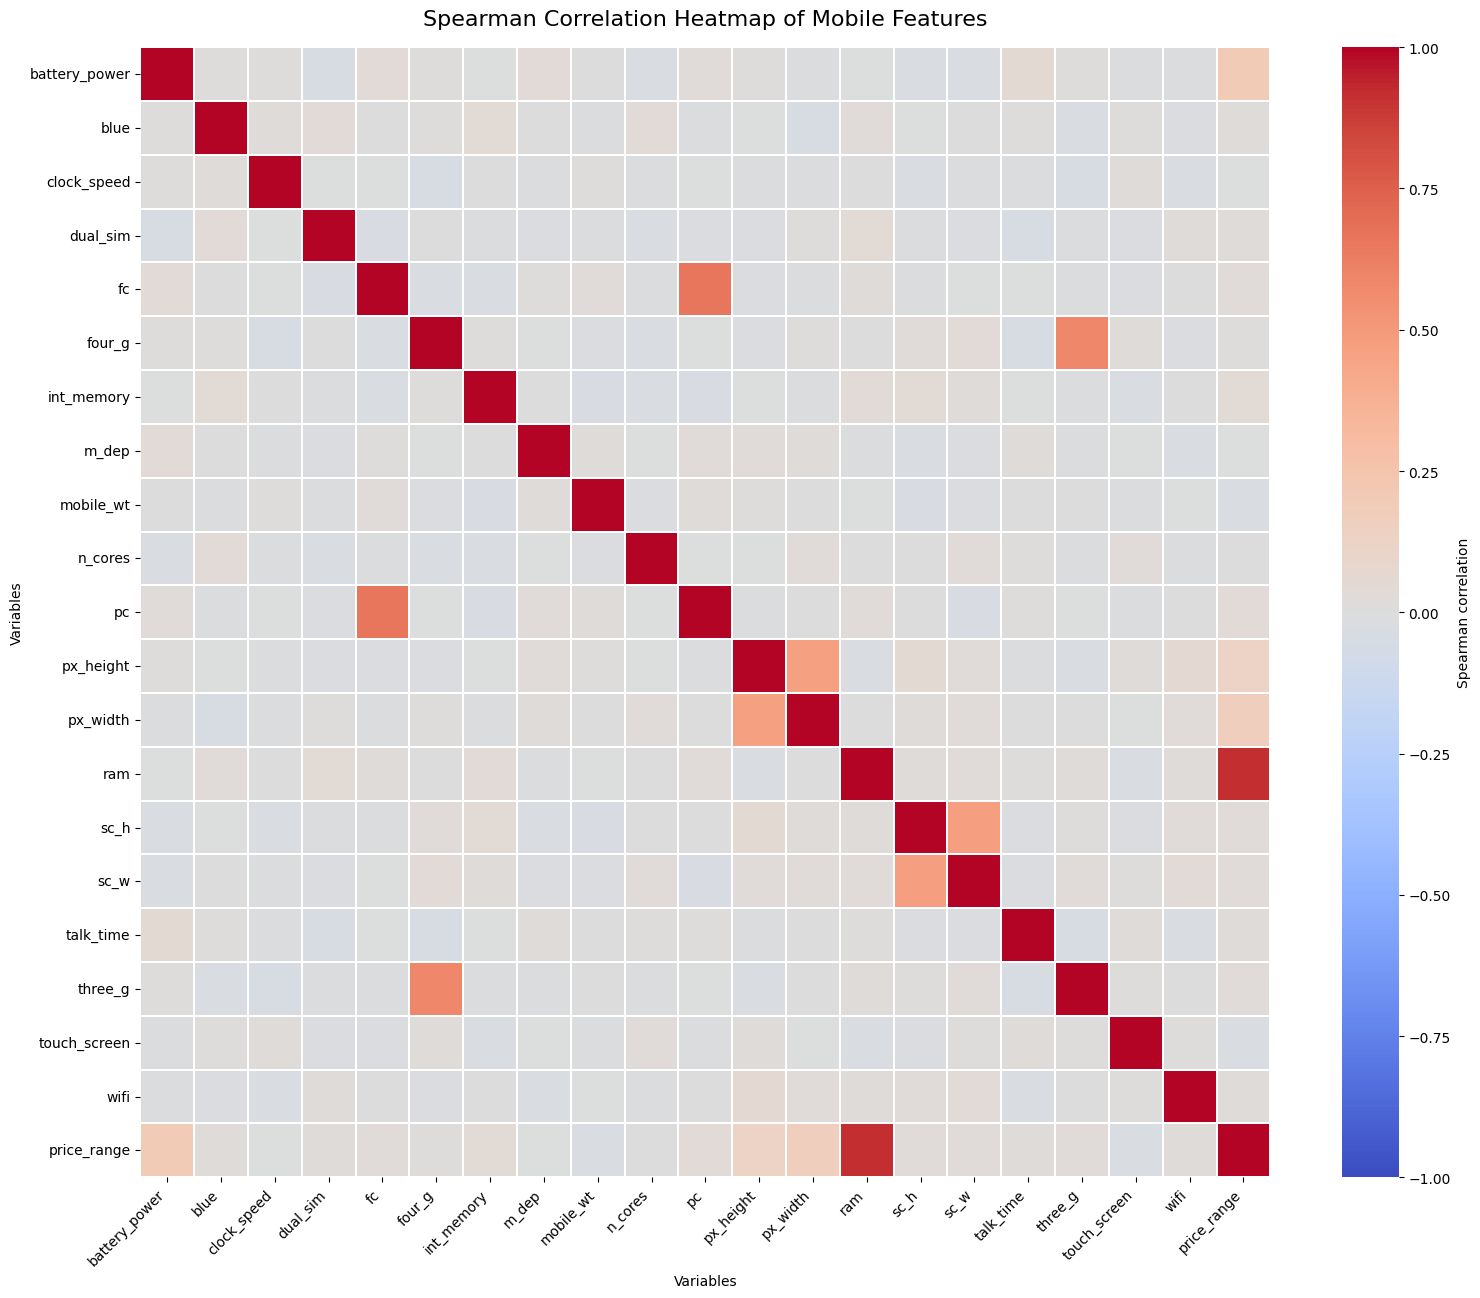

In [23]:
# Spearman correlation heatmap, including the ordinal target
heatmap_columns = numeric_cols + [ordinal_target]
correlation_matrix = df[heatmap_columns].corr(method="spearman")

plt.figure(figsize=(16, 13))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Spearman correlation"}
    )
plt.title("Spearman Correlation Heatmap of Mobile Features", fontsize=16, pad=16)
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Insight Synthesis and Conclusion

In [24]:
# Combine association strength and group-test evidence
evidence_summary = correlation_summary.merge(
    hypothesis_summary[[
        "feature", "kruskal_statistic", "epsilon_squared",
        "significant_after_bonferroni"
    ]],
    on="feature",
    suffixes=("_correlation", "_group_test")
)

evidence_summary[[
    "feature", "spearman_correlation", "p_value",
    "epsilon_squared", "significant_after_bonferroni_group_test"
]].head(10)

,feature,spearman_correlation,p_value,epsilon_squared,significant_after_bonferroni_group_test
0,ram,0.917080,0.000000e+00,0.840930,True
1,battery_power,0.199991,1.722306e-19,0.043655,True
2,px_width,0.165134,1.074056e-13,0.031178,True
3,px_height,0.131884,3.215011e-09,0.022135,True
4,int_memory,0.044278,4.771653e-02,0.002890,False
5,pc,0.032824,1.422683e-01,0.000000,False
6,touch_screen,-0.030411,1.739918e-01,0.000440,False
7,mobile_wt,-0.030214,1.767996e-01,0.003917,False
8,sc_w,0.024776,2.680838e-01,0.000000,False
9,fc,0.024167,2.800284e-01,0.000000,False


### Conclusions

- **RAM is the dominant determinant of mobile price classification.** It has a very strong positive Spearman association with `price_range` (rho = 0.917). Its Kruskal-Wallis effect size is also very large (epsilon-squared = 0.841), and the box plots show clear separation between all four price classes. Median RAM rises from 719.5 MB in class 0 to 3,509.5 MB in class 3.
- **Battery power and screen resolution are secondary determinants.** `battery_power` (rho = 0.200), `px_width` (rho = 0.165), and `px_height` (rho = 0.132) all remain statistically significant after the Bonferroni correction. Their effect sizes are much smaller than RAM's, so they provide supporting rather than dominant separation.
- **Most remaining features have weak individual relationships with price.** Connectivity flags such as Bluetooth, 4G, Wi-Fi, dual-SIM support, and touch-screen support show correlations close to zero and negligible group differences. Clock speed and the number of processor cores are also unexpectedly weak on their own.
- **The distribution analysis reveals some asymmetry.** Front-camera megapixels are strongly right-skewed, while pixel height and screen width are moderately right-skewed. Most other measurement features are approximately symmetric.
- **The target is perfectly balanced.** Each price class contains 500 observations, so the analysis is not being driven by class imbalance.

Overall, RAM is the clearest determinant of price class, followed at a considerable distance by battery power and pixel dimensions. These are bivariate findings: statistical significance and correlation do not prove causation or replace multivariable model-based feature importance.